In [14]:
pip install pmdarima

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 66.1 MB/s eta 0:00:00


In [15]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.metrics import r2_score

In [16]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
data = pd.read_csv(io.StringIO(uploaded['US Wheat Futures Historical Data.csv'].decode('utf-8')))

Saving US Wheat Futures Historical Data.csv to US Wheat Futures Historical Data (1).csv


In [17]:
# Converting "Price", "Open", "High", "Low", "Vol." columns to float datatype
data['Price'] = data['Price'].str.replace(',', '').astype(float)
data['Open'] = data['Open'].str.replace(',', '').astype(float)
data['High'] = data['High'].str.replace(',', '').astype(float)
data['Low'] = data['Low'].str.replace(',', '').astype(float)
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000.
print(data.dtypes)

Date         object
Price       float64
Open        float64
High        float64
Low         float64
Vol.        float64
Change %     object
dtype: object


<Axes: >

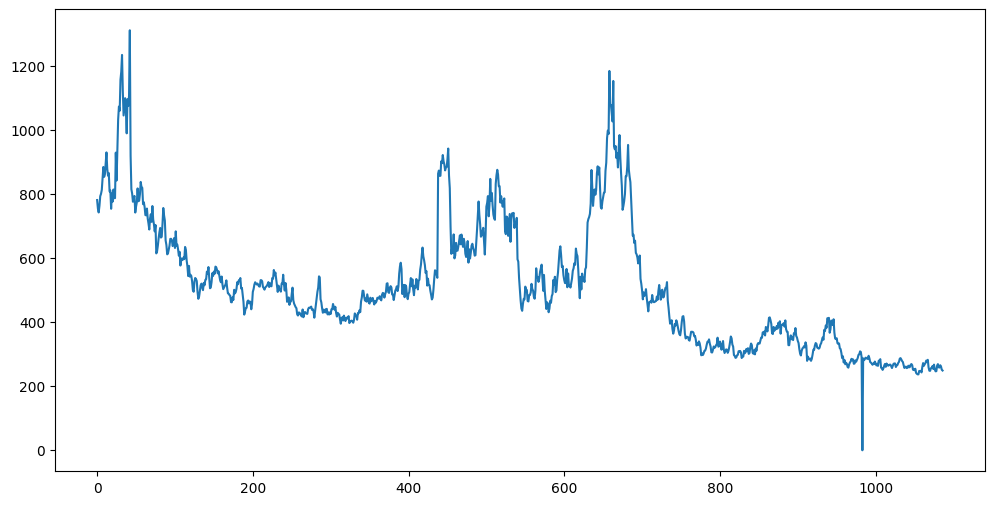

In [20]:
data["Open"].plot(figsize=(12,6))

In [21]:
# Dickey - Fuller Test
from statsmodels.tsa.stattools import adfuller

def ad_test(dataset):
  dftest = adfuller(dataset, autolag ='AIC')
  print("1. ADF: ", dftest[0])
  print("2. p-value: ", dftest[1])
  print("3. No. of lags: ", dftest[2])
  print("4. No. of observations used for ADF Regression and Critical Values Calculations: ", dftest[3])
  print("5. Critical Values: ")
  for key, val in dftest[4].items():
    print("\t", key, ",", val)

In [22]:
ad_test(data['Price'])

1. ADF:  -2.080254015937831
2. p-value:  0.2525283241066988
3. No. of lags:  17
4. No. of observations used for ADF Regression and Critical Values Calculations:  1069
5. Critical Values: 
	 1% , -3.4364819663568262
	 5% , -2.864247479652846
	 10% , -2.568211560046239


In [23]:
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

In [24]:
stepwise_fit = auto_arima(data['Price'], trace=True, suppress_warnings=True)
stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=10631.013, Time=0.85 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=10654.296, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=10641.063, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=10641.208, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=10652.549, Time=0.06 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=10642.244, Time=0.90 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=10638.857, Time=1.34 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=10632.897, Time=1.16 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=10632.899, Time=1.33 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=10643.014, Time=0.32 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=10637.362, Time=0.78 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=10633.784, Time=0.96 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=10619.354, Time=1.84 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=10620.403, Time=2.58 sec
 ARIMA(3,1,4)(0,0,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1087
Model:               SARIMAX(3, 1, 3)   Log Likelihood               -5301.778
Date:                Sun, 11 Jun 2023   AIC                          10617.555
Time:                        06:02:04   BIC                          10652.487
Sample:                             0   HQIC                         10630.779
                               - 1087                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -2.2579      0.119    -18.909      0.000      -2.492      -2.024
ar.L2         -1.7575      0.225     -7.802      0.000      -2.199      -1.316
ar.L3         -0.4766      0.114     -4.167      0.000      -0.701      -0.252
ma.L1          2.1595      0.126     17.111      0.000       1.912       2.407
ma.L2          1.5067      0.242      6.220      0.000       1.032       1.981
ma.L3          0.3165      0.124      2.548      0.011       0.073       0.560
sigma2      1018.1577     17.102     59.534      0.000     984.638    1051.677
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):            111221.52
Prob(Q):                              0.85   Prob(JB):                         0.00
Heteroskedasticity (H):               0.13   Skew:                            -1.32
Prob(H) (two-sided):                  0.00   Kurtosis:                        52.51
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [25]:
# Convert the "date" column to a datetime object
data['Date'] = pd.to_datetime(data['Date'])

In [26]:
# Drop the columns you don't need
data = data.drop(["Change %"], axis=1)

In [27]:
import statsmodels.api as sm

In [28]:
"""
# Spllitting the dataset
print(data.shape)
train=data.iloc[:-30]
test=data.iloc[-30:]
print(train.shape, test.shape)
"""

'\n# Spllitting the dataset\nprint(data.shape)\ntrain=data.iloc[:-30]\ntest=data.iloc[-30:]\nprint(train.shape, test.shape)\n'

In [29]:
# extract features and target
X = data[['Open', 'High', 'Low','Vol.']]
y = data['Price']

In [30]:
# Addition
# Select the rows for the training set (2000-2019)
train_X = X[data['Date'].dt.year.between(2000, 2019)]
train_y = y[data['Date'].dt.year.between(2000, 2019)]

# Select the rows for the test set (2020-2022)
test_X = X[data['Date'].dt.year.between(2020, 2022)]
test_y = y[data['Date'].dt.year.between(2020, 2022)]

In [31]:
# Taining the model
model=sm.tsa.arima.ARIMA(train_y, order=(1,0,5))
model=model.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Price   No. Observations:                  931
Model:                 ARIMA(1, 0, 5)   Log Likelihood               -4373.932
Date:                Sun, 11 Jun 2023   AIC                           8763.864
Time:                        06:02:05   BIC                           8802.554
Sample:                             0   HQIC                          8778.620
                                - 931                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        475.6019     91.296      5.209      0.000     296.664     654.539
ar.L1          0.9849      0.005    180.560      0.000       0.974       0.996
ma.L1         -0.0048      0.025     -0.187      0.851      -0.055       0.045
ma.L2          0.0559      0.029      1.960      0.050    1.15e-05       0.112
ma.L3          0.0286      0.026      1.096      0.273      -0.023       0.080
ma.L4         -0.0261      0.029     -0.889      0.374      -0.084       0.031
ma.L5          0.0814      0.025      3.233      0.001       0.032       0.131
sigma2       702.2223     11.317     62.052      0.000     680.042     724.403
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):             26564.86
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               0.20   Skew:                             2.05
Prob(H) (two-sided):                  0.00   Kurtosis:                        28.85
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [32]:
# Make predictions on the Test dataset
start = len(test_y)
end = len(test_y) + len(test_y)-1
pred = model.predict(start=start, end=end, type='levels')
print(pred)
pred.index = data.index[start:end+1]
print(pred)

312    428.246512
313    422.736986
314    407.311985
315    395.390534
316    408.549838
          ...    
463    642.044033
464    627.282340
465    612.857021
466    654.879429
467    658.566799
Name: predicted_mean, Length: 156, dtype: float64
156    428.246512
157    422.736986
158    407.311985
159    395.390534
160    408.549838
          ...    
307    642.044033
308    627.282340
309    612.857021
310    654.879429
311    658.566799
Name: predicted_mean, Length: 156, dtype: float64


<Axes: >

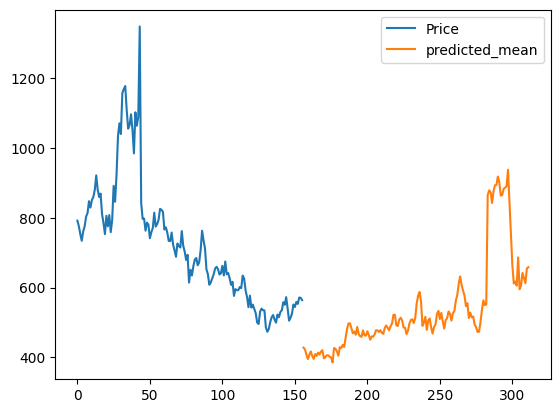

In [33]:
# Plotting the predicted values and the test set
test_y.plot(legend=True)
pred.plot(legend=True)

In [34]:
test_y.mean()

718.5805769230769

In [35]:
from sklearn.metrics import mean_squared_error
from math import sqrt

rmse=sqrt(mean_squared_error(test_y, pred))
print(rmse)

327.754128162209
